In [1]:
from gtracr.geomagnetic_cutoffs import GMRC

# initialize geomagnetic rigidity cutoff evaluator at Kamioka
# with 10000 iterations
gmrc = GMRC(
    "ORCA",
    solver="rk45",
    bfield_type="table",
    iter_num=500000,
    min_rigidity=0.5,
    max_rigidity=80.0,
)

# evaluate with default stepsize and max_time
gmrc.evaluate_batch()

Initializing batch GMRC for ORCA (500000 samples, 12 threads, table)...
Initialized in 0.00s. Running cutoff calculations...
Completed 500000 cutoffs in 10.51s (4043553 trajectories, 384.8k traj/s across 12 threads, 10.51s total)


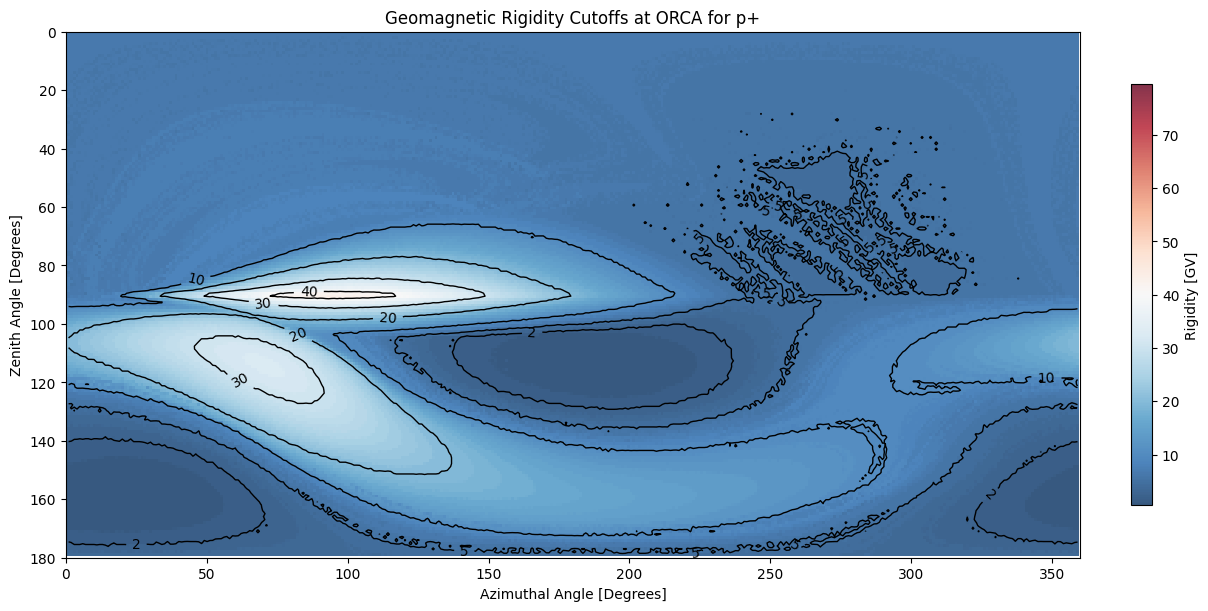

In [2]:
# interpolate results
interpd_gmrc_data = gmrc.interpolate_results(ngrid_azimuth=360, ngrid_zenith=180)

# create heatmap and save as png
from gtracr.plotting import plot_gmrc_heatmap

plot_gmrc_heatmap(
    interpd_gmrc_data,
    gmrc.rigidity_list,
    locname=gmrc.location,
    plabel=gmrc.plabel,
    bfield_type=gmrc.bfield_type,
)